In [1]:
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

In [2]:
##sample names are: m5,p5_1,p5_2,m4,p5

In [3]:
gray_green = LinearSegmentedColormap.from_list(
    "gray_green", ["#D3D3D3", "#02500e", "#001203"]
)
gray_orange = LinearSegmentedColormap.from_list(
    "gray_orange", ["#D3D3D3", "#f76d48", "#FA4616"]
)

In [4]:
sc.settings.figdir = "/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/m345/figures"
adata_transformed = ad.read_h5ad("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/m345/data/processed/m345_adata_clustered_(32,40)_(0.15,1.1)_8_3_25.h5ad")

/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


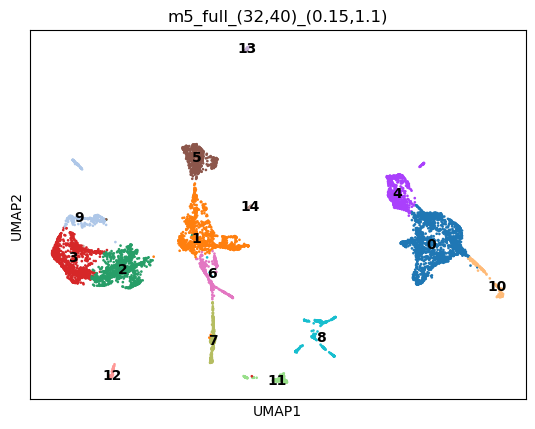

In [14]:
sc.pl.umap(adata_transformed,color="leiden",cmap="viridis", 
          legend_loc="on data", title = "m5_full_(32,40)_(0.15,1.1)",
         save="m5_full_(32,40)_(0.15,1.1).pdf"
          )

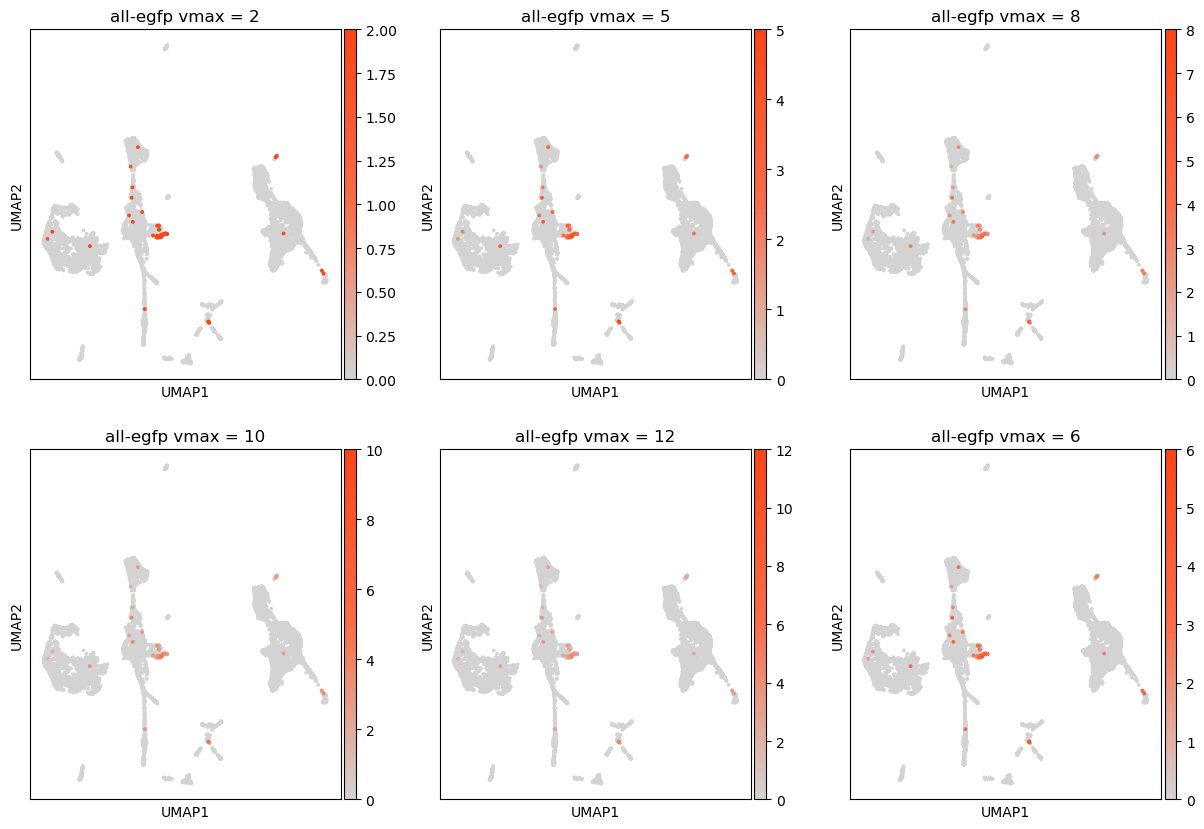

In [69]:
#vmax_values = [12,15,18,20,22,25]
vmax_values = [2,5,8,10,12,6]
gene="egfp"

ncols = 3
nrows = (len(vmax_values) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 5 * nrows))

axes = axes.flatten()

for i, vmax in enumerate(vmax_values):
    ax = axes[i]
    sc.pl.umap(
        adata_transformed,
        color=gene,
        vmin=0,
        vmax=vmax,
        size=30,
        title=f"all-{gene} vmax = {vmax}",
        cmap=gray_orange,
        show=False,
        ax=ax  
    )

In [15]:
import anndata as ad
import h5py
import scvelo as scv
import warnings
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import warnings
import pandas as pd
from joblib import Parallel, delayed
import numpy as np

In [17]:
scv.settings.verbosity = 3  
scv.settings.presenter_view = True 
scv.set_figure_params('scvelo') 
scv.settings.figdir = "/blue/square.t/peter.huynh/jupyter/m345/results/"
warnings.filterwarnings("ignore", category=DeprecationWarning)

Filtered out 117 genes that are detected 20 counts (spliced).
Normalized count data: X, spliced, unspliced.


/scratch/local/10633246/ipykernel_3694078/4293888177.py:15: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata_velocity, n_pcs=32, n_neighbors=40)
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/preprocessing/neighbors.py:233: DeprecationWarning: Automatic computation of PCA is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute PCA with Scanpy first.
  _set_pca(adata=adata, n_pcs=n_pcs, use_highly_variable=use_highly_variable)


computing neighbors
    finished (0:01:12) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:04) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 8/128 cores)
or disable the progress bar using `show_progress_bar=False`.
    finished (0:05:06) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:01) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


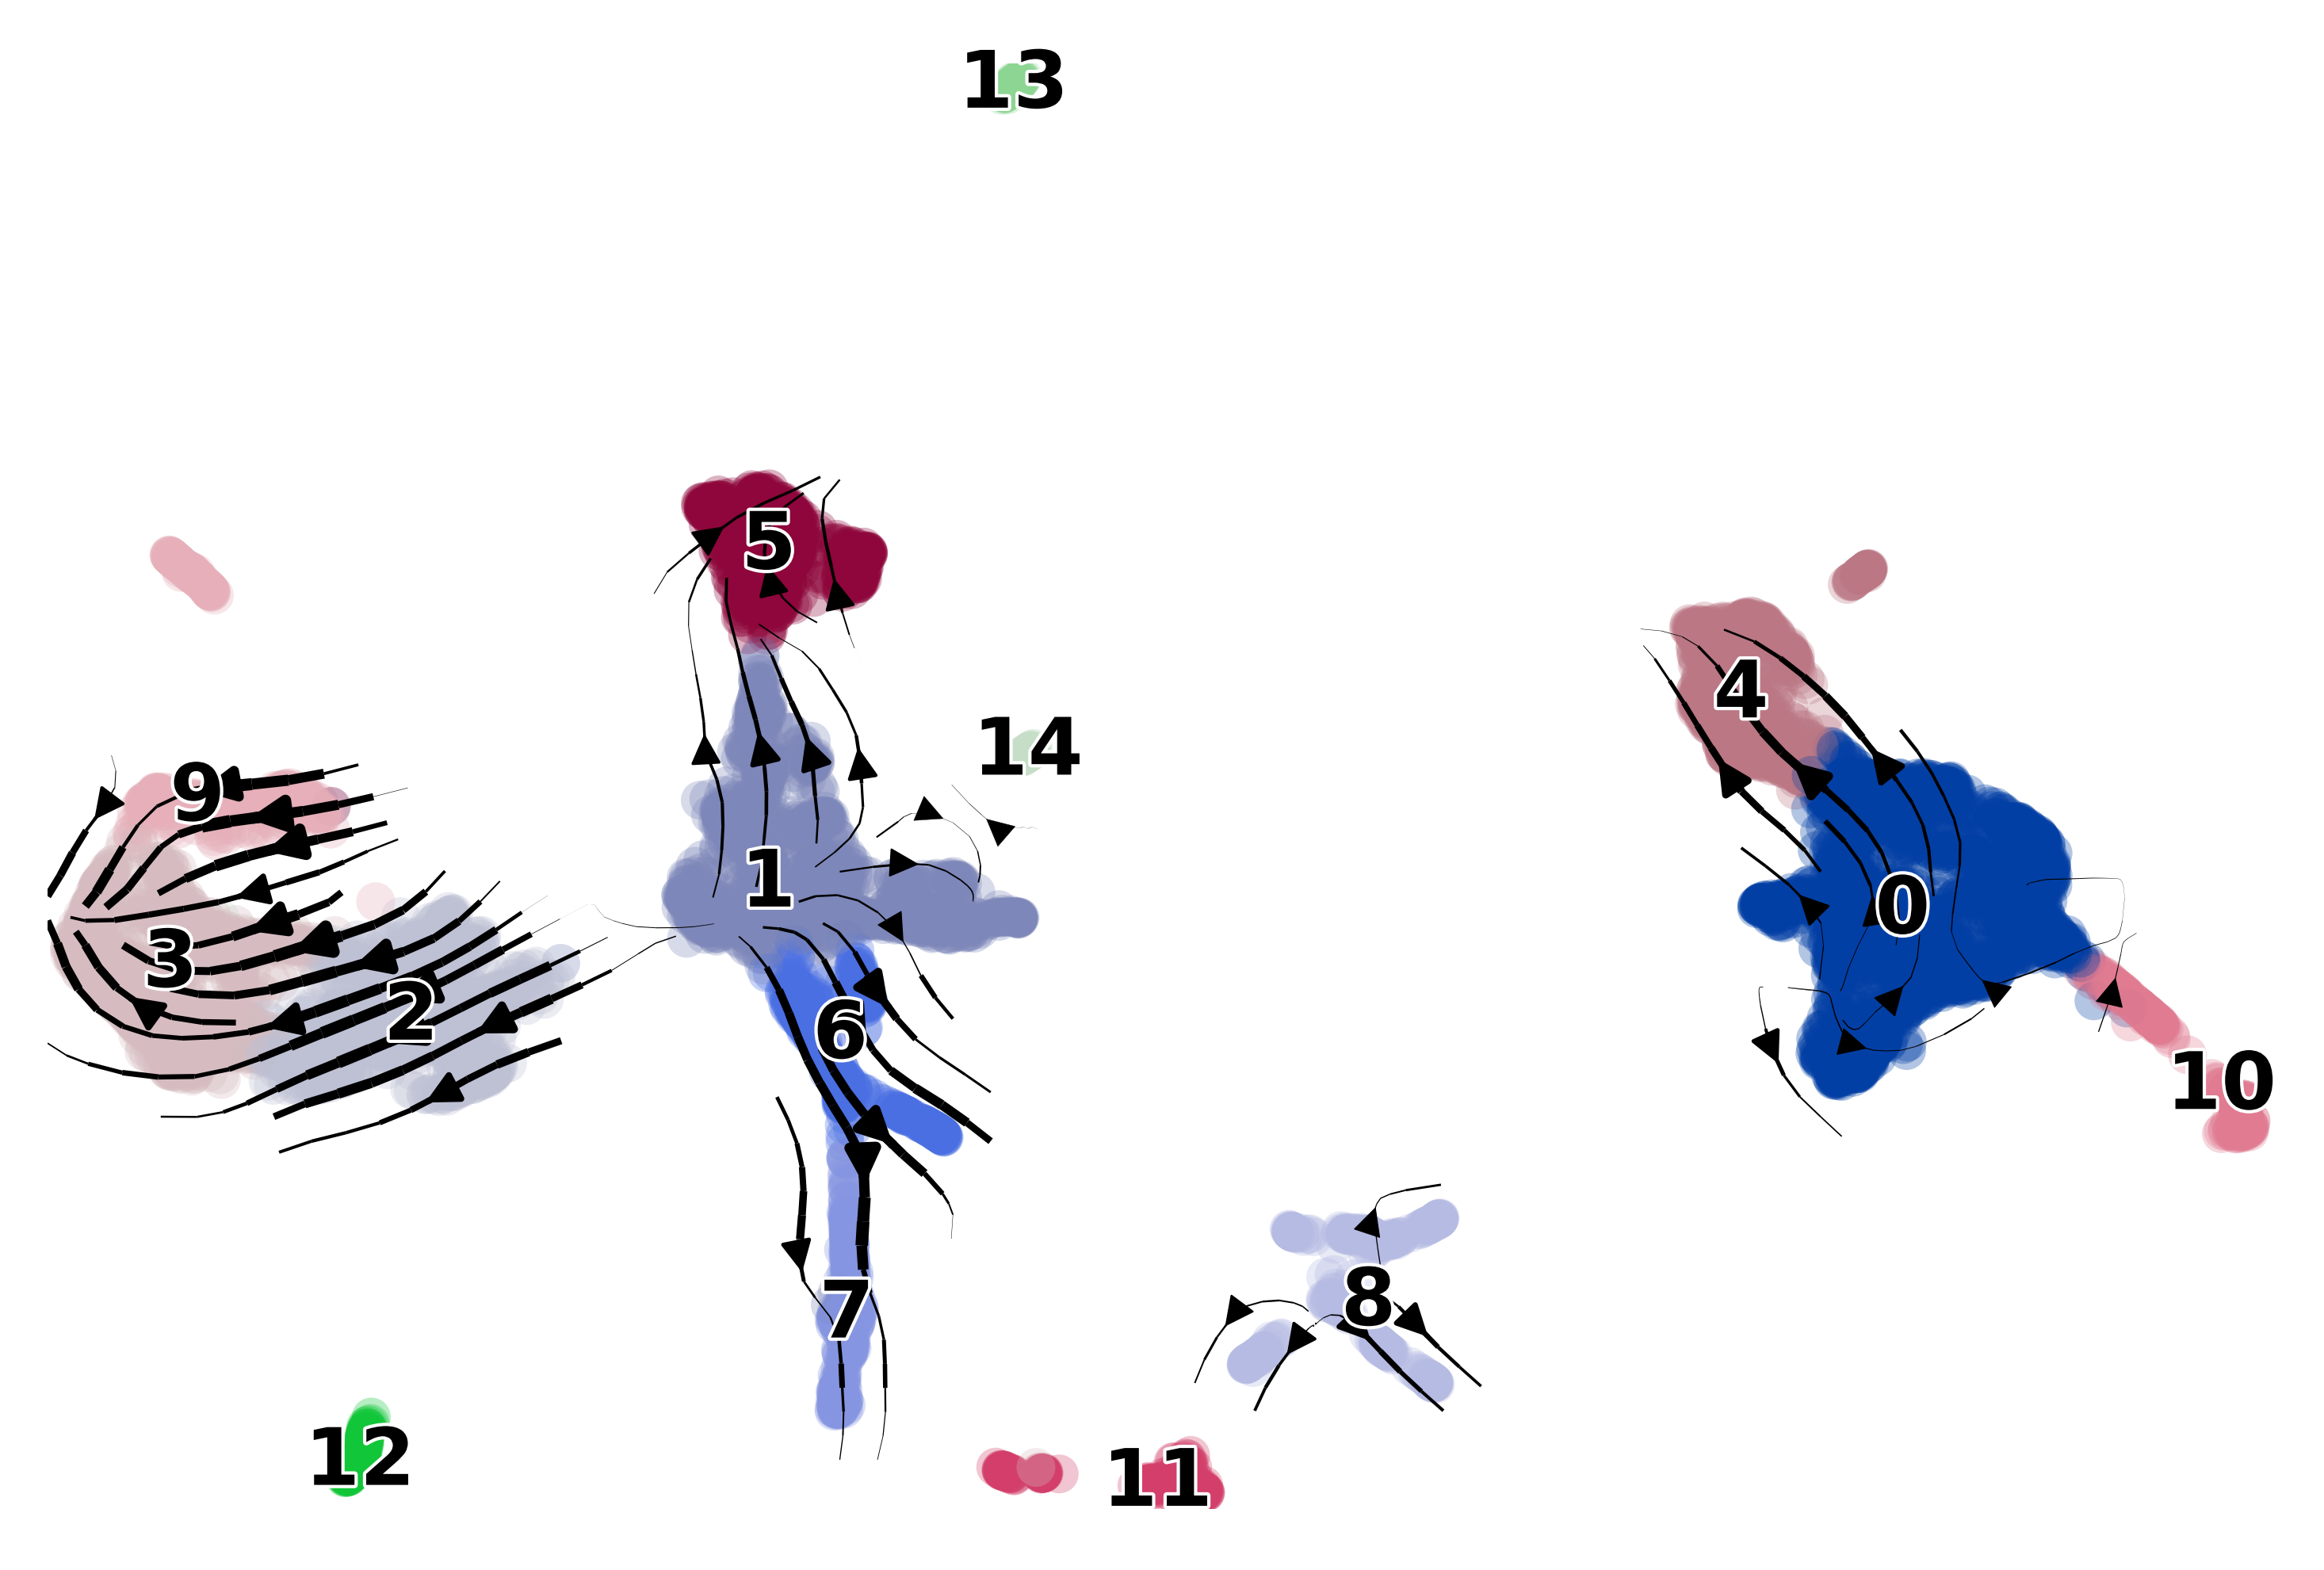

In [19]:
adata = ad.read_h5ad("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/m345/data/processed/m345_adata_scrubleted_egfp.h5ad")
adata_raw = adata.copy() 
adata_raw = adata_raw[adata_transformed.obs_names, :].copy()
adata_raw = adata_raw[:, adata_transformed.var_names].copy()
adata_raw.obsm["X_umap"] = adata_transformed.obsm["X_umap"]
adata_raw.obs["leiden"]  = adata_transformed.obs["leiden"]
adata_velocity=adata_raw.copy()
scv.pp.filter_and_normalize(
    adata_velocity,
    min_counts=20,
    min_cells=5,
    n_top_genes=None, 
    log=False
)
scv.pp.moments(adata_velocity, n_pcs=32, n_neighbors=40)
scv.tl.velocity(adata_velocity, mode="stochastic", n_jobs=8)
scv.tl.velocity_graph(adata_velocity, n_jobs=8)
scv.pl.velocity_embedding_stream(adata_velocity, basis='umap',dpi=300,color="leiden", title="",
                                 #save="plus345_2_subset_velocity_stream_grey.svg"
                                )